In [1]:
import os
import multiprocessing
import torch
import pandas as pd
import numpy as np
import mpl_scatter_density
from transformers import BertConfig
from geomstats.geometry.torus import Torus
from schedule import LinearBetaSchedule
from sde_lib import DiffusionMixture
from solver import get_pc_sampler
from foldingdiff.bert_for_diffusion import BertForDiffusion
from foldingdiff.angles_and_coords import create_new_chain_nerf
from Bio.PDB import PDBParser
import nglview as nv
import torch.nn.functional as F
from tqdm import tqdm
from matplotlib import pyplot as plt
from foldingdiff.sampling import plot_distribution_overlap, FT_NAME_MAP, plot_ramachandran
from foldingdiff.bin.annot_secondary_structures import make_ss_cooccurrence_plot
from foldingdiff.datasets import CathCanonicalAnglesOnlyDataset
from foldingdiff import custom_metrics as cm

/home/samir/Documents/Doutorado/riemannian-diffusion-mixture-torch/.venv/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
max_seq_len = 128
min_seq_len = 40
ft_names = ["phi", "psi", "omega", "tau", "CA:C:1N", "C:1N:1CA"]

In [4]:
angles_per_residue = 6
cfg = BertConfig(
    max_position_embeddings=max_seq_len,
    num_attention_heads=4,
    hidden_size=96,
    intermediate_size=192,
    num_hidden_layers=4,
    position_embedding_type="relative_key",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    use_cache=False,
    _attn_implementation="eager"
)

modelf = BertForDiffusion(config=cfg, ft_names=ft_names).to(device)
modelf.load_state_dict(torch.load('./forward_bert.pt', weights_only=True))

<All keys matched successfully>

In [5]:
modelf

BertForDiffusion(
  (inputs_to_hidden_dim): Linear(in_features=12, out_features=96, bias=True)
  (embeddings): Sequential(
    (0): LayerNorm((96,), eps=1e-12, elementwise_affine=True)
    (1): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-3): 4 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=96, out_features=96, bias=True)
            (key): Linear(in_features=96, out_features=96, bias=True)
            (value): Linear(in_features=96, out_features=96, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
            (distance_embedding): Embedding(255, 24)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=96, out_features=96, bias=True)
            (LayerNorm): LayerNorm((96,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (intermediate): Ber

In [78]:
modelb = BertForDiffusion(config=cfg, ft_names=ft_names).to(device)
modelb.load_state_dict(torch.load('./backward_bert.pt', weights_only=True))

<All keys matched successfully>

In [79]:
beta_schedule = LinearBetaSchedule(beta_0=0.2, beta_f=0.001, t0=0, tf=1.0)   
mix = DiffusionMixture(
    beta_schedule,
    mix_type="log",
    drift_scale=1.0,
    pred=False,
    pred_scale=1.0,
    prior_type="unif",
)

In [80]:
fdrift_fn = mix.get_drift_fn(modelf)
bdrift_fn = mix.rev().get_drift_fn(modelb)
sde = mix.approx(fdrift_fn, bdrift_fn, True)

In [81]:
def sample(n_residues, n_samples=1, n_steps=500):
    manifold = Torus((n_residues - 1) * 6)
    shape = (n_samples,)
    sampler = get_pc_sampler(manifold=manifold, sde=sde, shape=shape, N=n_steps, eps=0.001, device=device)
    _sample = sampler(prior_samples=None)

    angles_rec = torch.atan2(_sample[:, 1::2], _sample[:, 0::2])
    angles_rec = F.pad(angles_rec, (1, angles_per_residue - 1), "constant", 0)
    angles_rec = angles_rec.reshape(shape[0], -1, angles_per_residue)
    return angles_rec

def write_pdb(angles, out_path):
    df_rec = pd.DataFrame(angles, columns=ft_names)
    rec_pdb = create_new_chain_nerf(out_path, df_rec)
    return rec_pdb

In [75]:
samples = []

In [76]:
os.makedirs('generations', exist_ok=True)
for n_residues in tqdm(range(min_seq_len, max_seq_len + 1)):
    protein_sample = sample(n_residues, n_samples=9, n_steps=1000)
    with multiprocessing.Pool(processes=9) as pool:
        results = pool.starmap(
            write_pdb,
            [
                (protein_sample[i].cpu().numpy(), f'generations/rec_prot_{n_residues}_sample_{i}.pdb')
                for i in range(protein_sample.shape[0])
            ],
        )
    samples.append(protein_sample.cpu().numpy())

100%|██████████| 89/89 [04:11<00:00,  2.83s/it]


In [77]:
len(samples)

89

In [78]:
ds_args = dict(
    pad=max_seq_len,
    min_length=min_seq_len,
    trim_strategy="leftalign",
    zero_center=False,
    toy=None,
    pdbs="cath",
)
test_dset = CathCanonicalAnglesOnlyDataset(split="test", **ds_args)

In [79]:
test_values = [
    test_dset.__getitem__(i, ignore_zero_center=True)['angles']
    for i in range(len(test_dset))
]
test_values_stacked = torch.cat(test_values, dim=0).cpu().numpy()

In [80]:
final_sampled_stacked = np.vstack([sample.reshape(-1, 6) for sample in samples])

In [81]:
final_sampled_stacked.shape

(67284, 6)

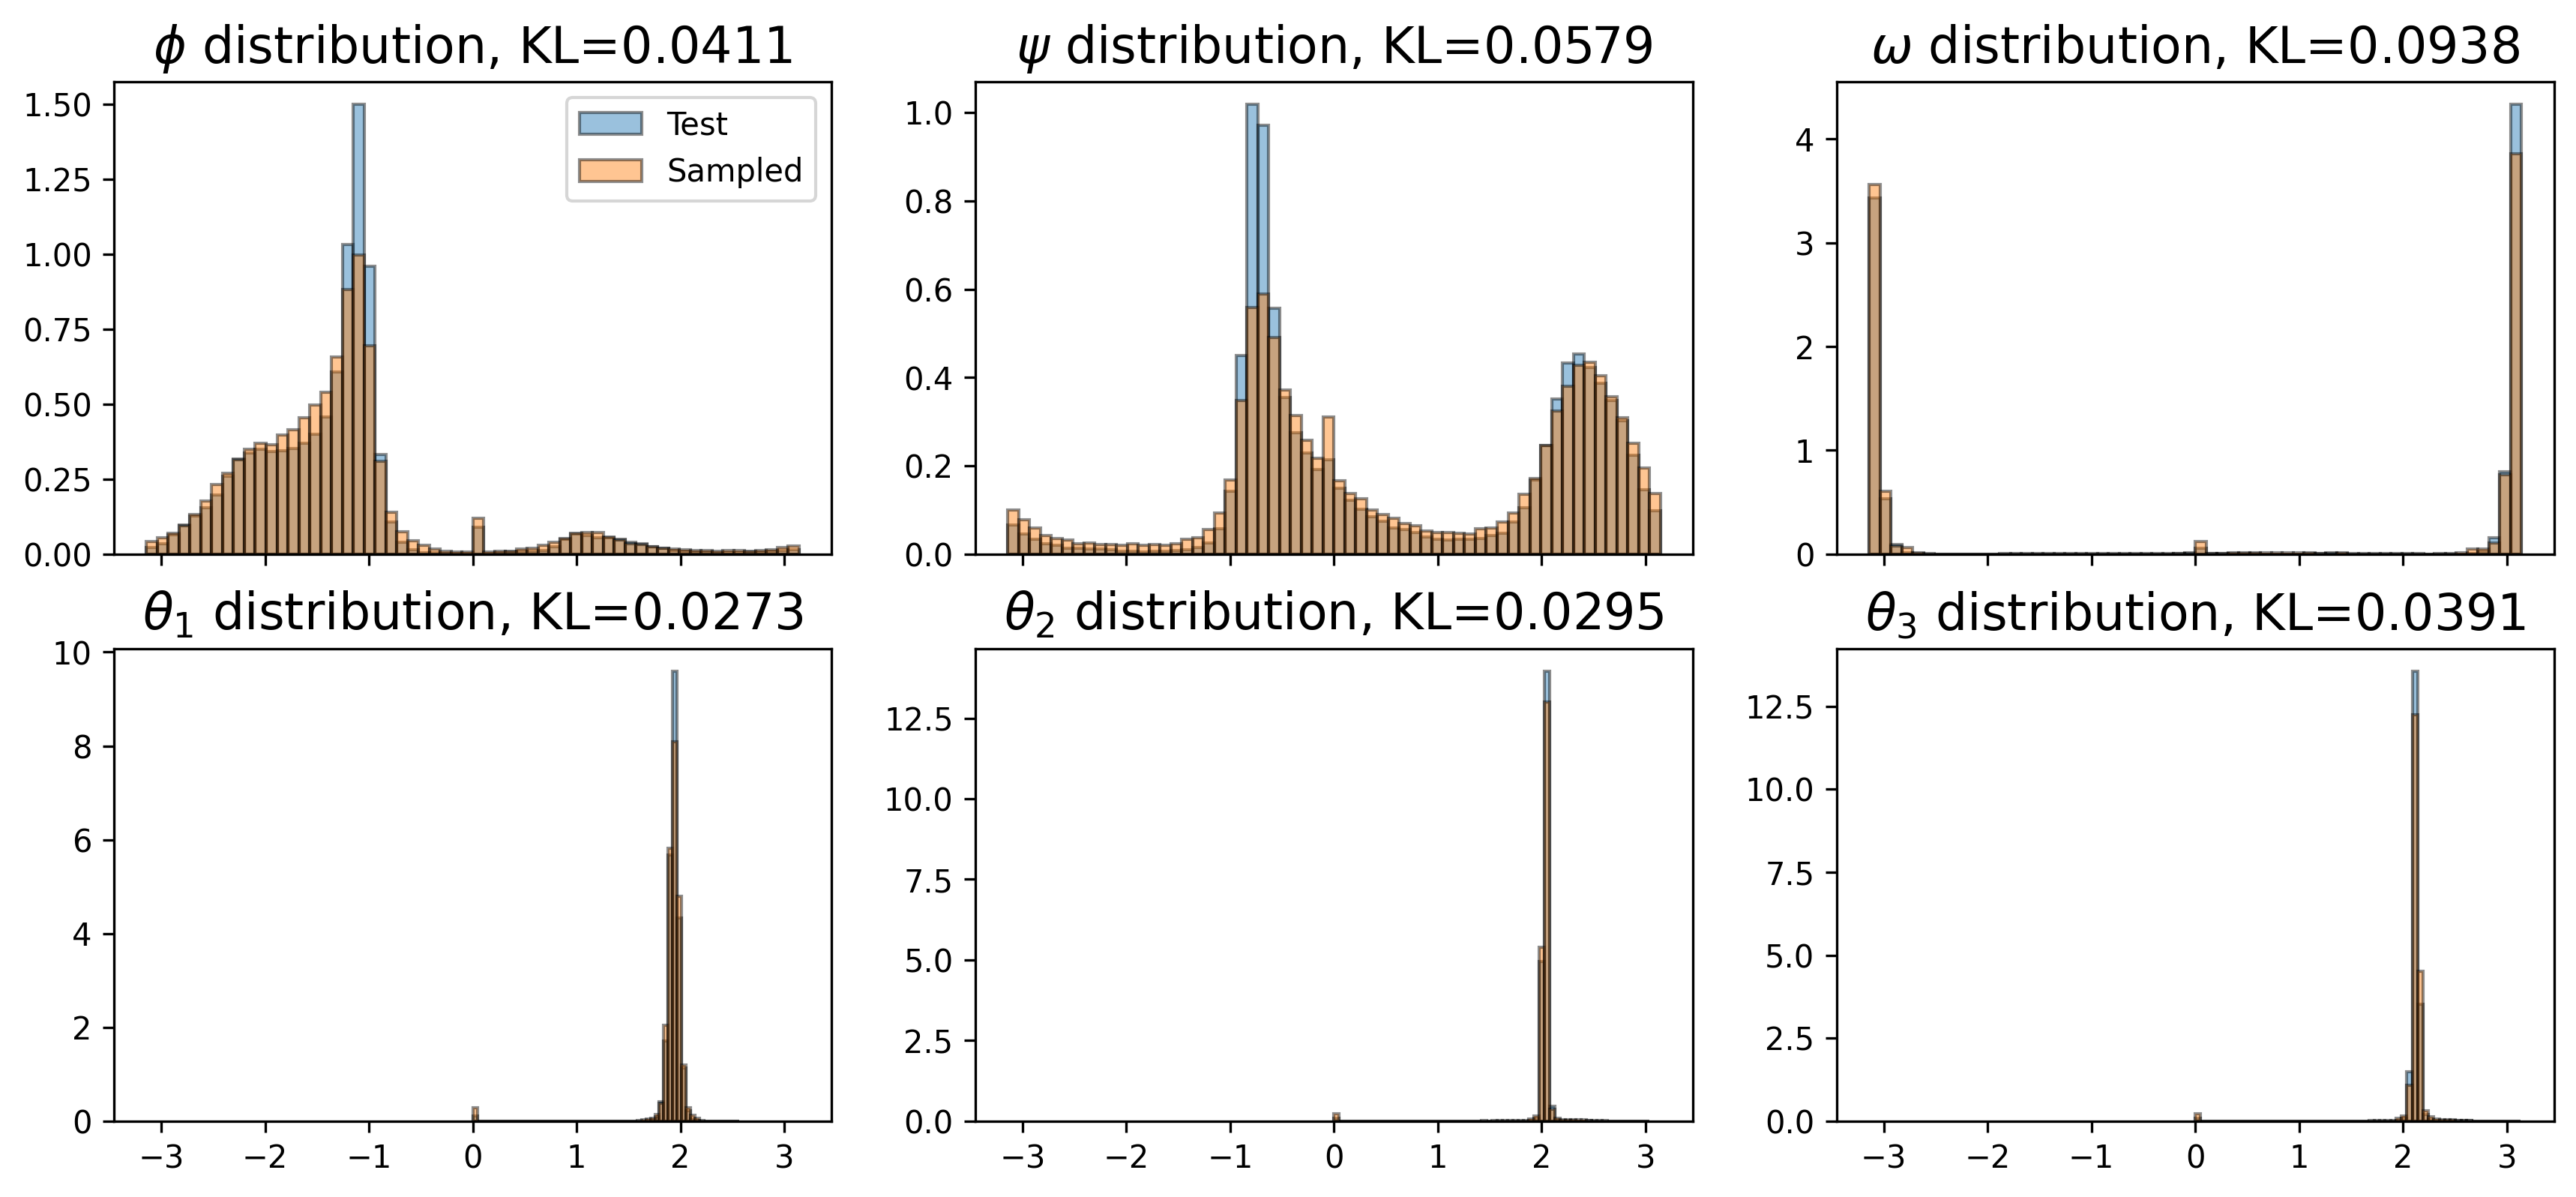

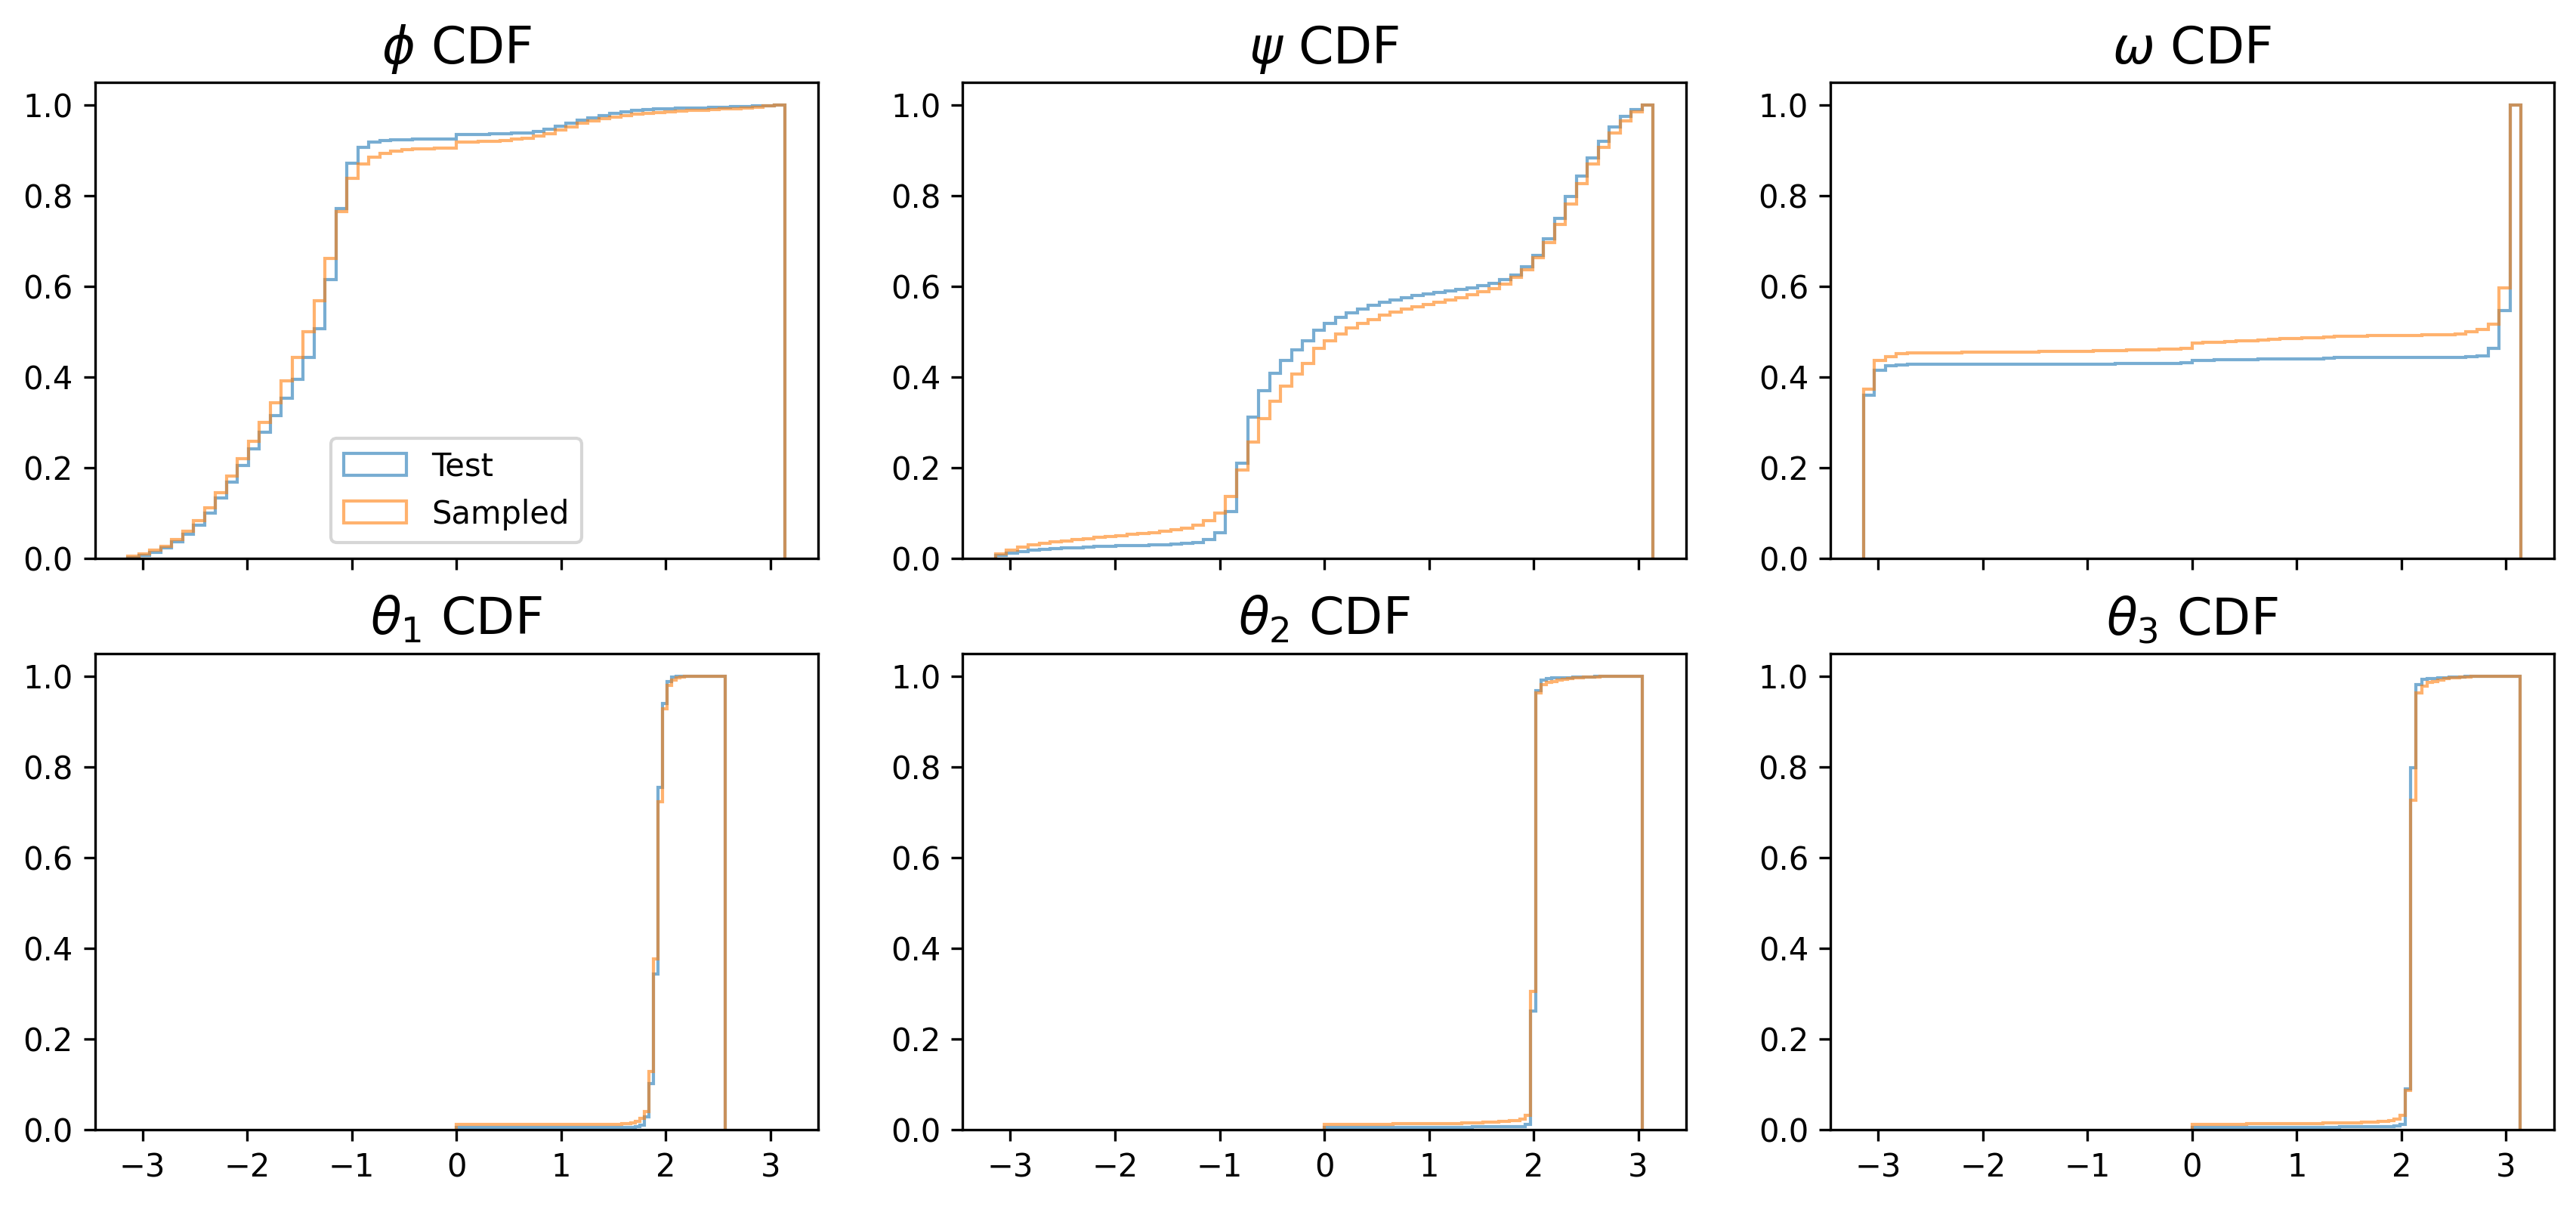

In [82]:
multi_fig, multi_axes = plt.subplots(
    dpi=300, nrows=2, ncols=3, figsize=(14, 6), sharex=True
)
step_multi_fig, step_multi_axes = plt.subplots(
    dpi=300, nrows=2, ncols=3, figsize=(14, 6), sharex=True
)
for i, ft_name in enumerate(ft_names):
    orig_values = (
        test_values_stacked[:20 * final_sampled_stacked.shape[0], i] if test_values_stacked is not None else None
    )
    samp_values = final_sampled_stacked[:, i]

    ft_name_readable = FT_NAME_MAP[ft_name]

    # Plot single plots
    # plot_distribution_overlap(
    #     {"Test": orig_values, "Sampled": samp_values},
    #     title=f"Sampled angle distribution - {ft_name_readable}",
    # )
    # plot_distribution_overlap(
    #     {"Test": orig_values, "Sampled": samp_values},
    #     title=f"Sampled angle CDF - {ft_name_readable}",
    #     histtype="step",
    #     cumulative=True,
    # )

    kl = cm.kl_from_empirical(samp_values, orig_values, nbins=200, pseudocount=True)

    # Plot combo plots
    plot_distribution_overlap(
        {"Test": orig_values, "Sampled": samp_values},
        title=f"{ft_name_readable} distribution, KL={kl:.4f}",
        edgecolor="black",
        ax=multi_axes.flatten()[i],
        show_legend=i == 0,
        alpha=0.45,
        bins=60,
    )
    plot_distribution_overlap(
        {"Test": orig_values, "Sampled": samp_values},
        title=f"{ft_name_readable} CDF",
        cumulative=True,
        histtype="step",
        ax=step_multi_axes.flatten()[i],
        show_legend=i == 0,
        alpha=0.6,
        bins=60,
    )

/home/jovyan/riemannian-diffusion-mixture-torch/.venv/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jovyan/riemannian-diffusion-mixture-torch/.venv/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/home/jovyan/riemannian-diffusion-mixture-torch/.venv/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jovyan/riemannian-diffusion-mixture-torch/.venv/lib/python3.12/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


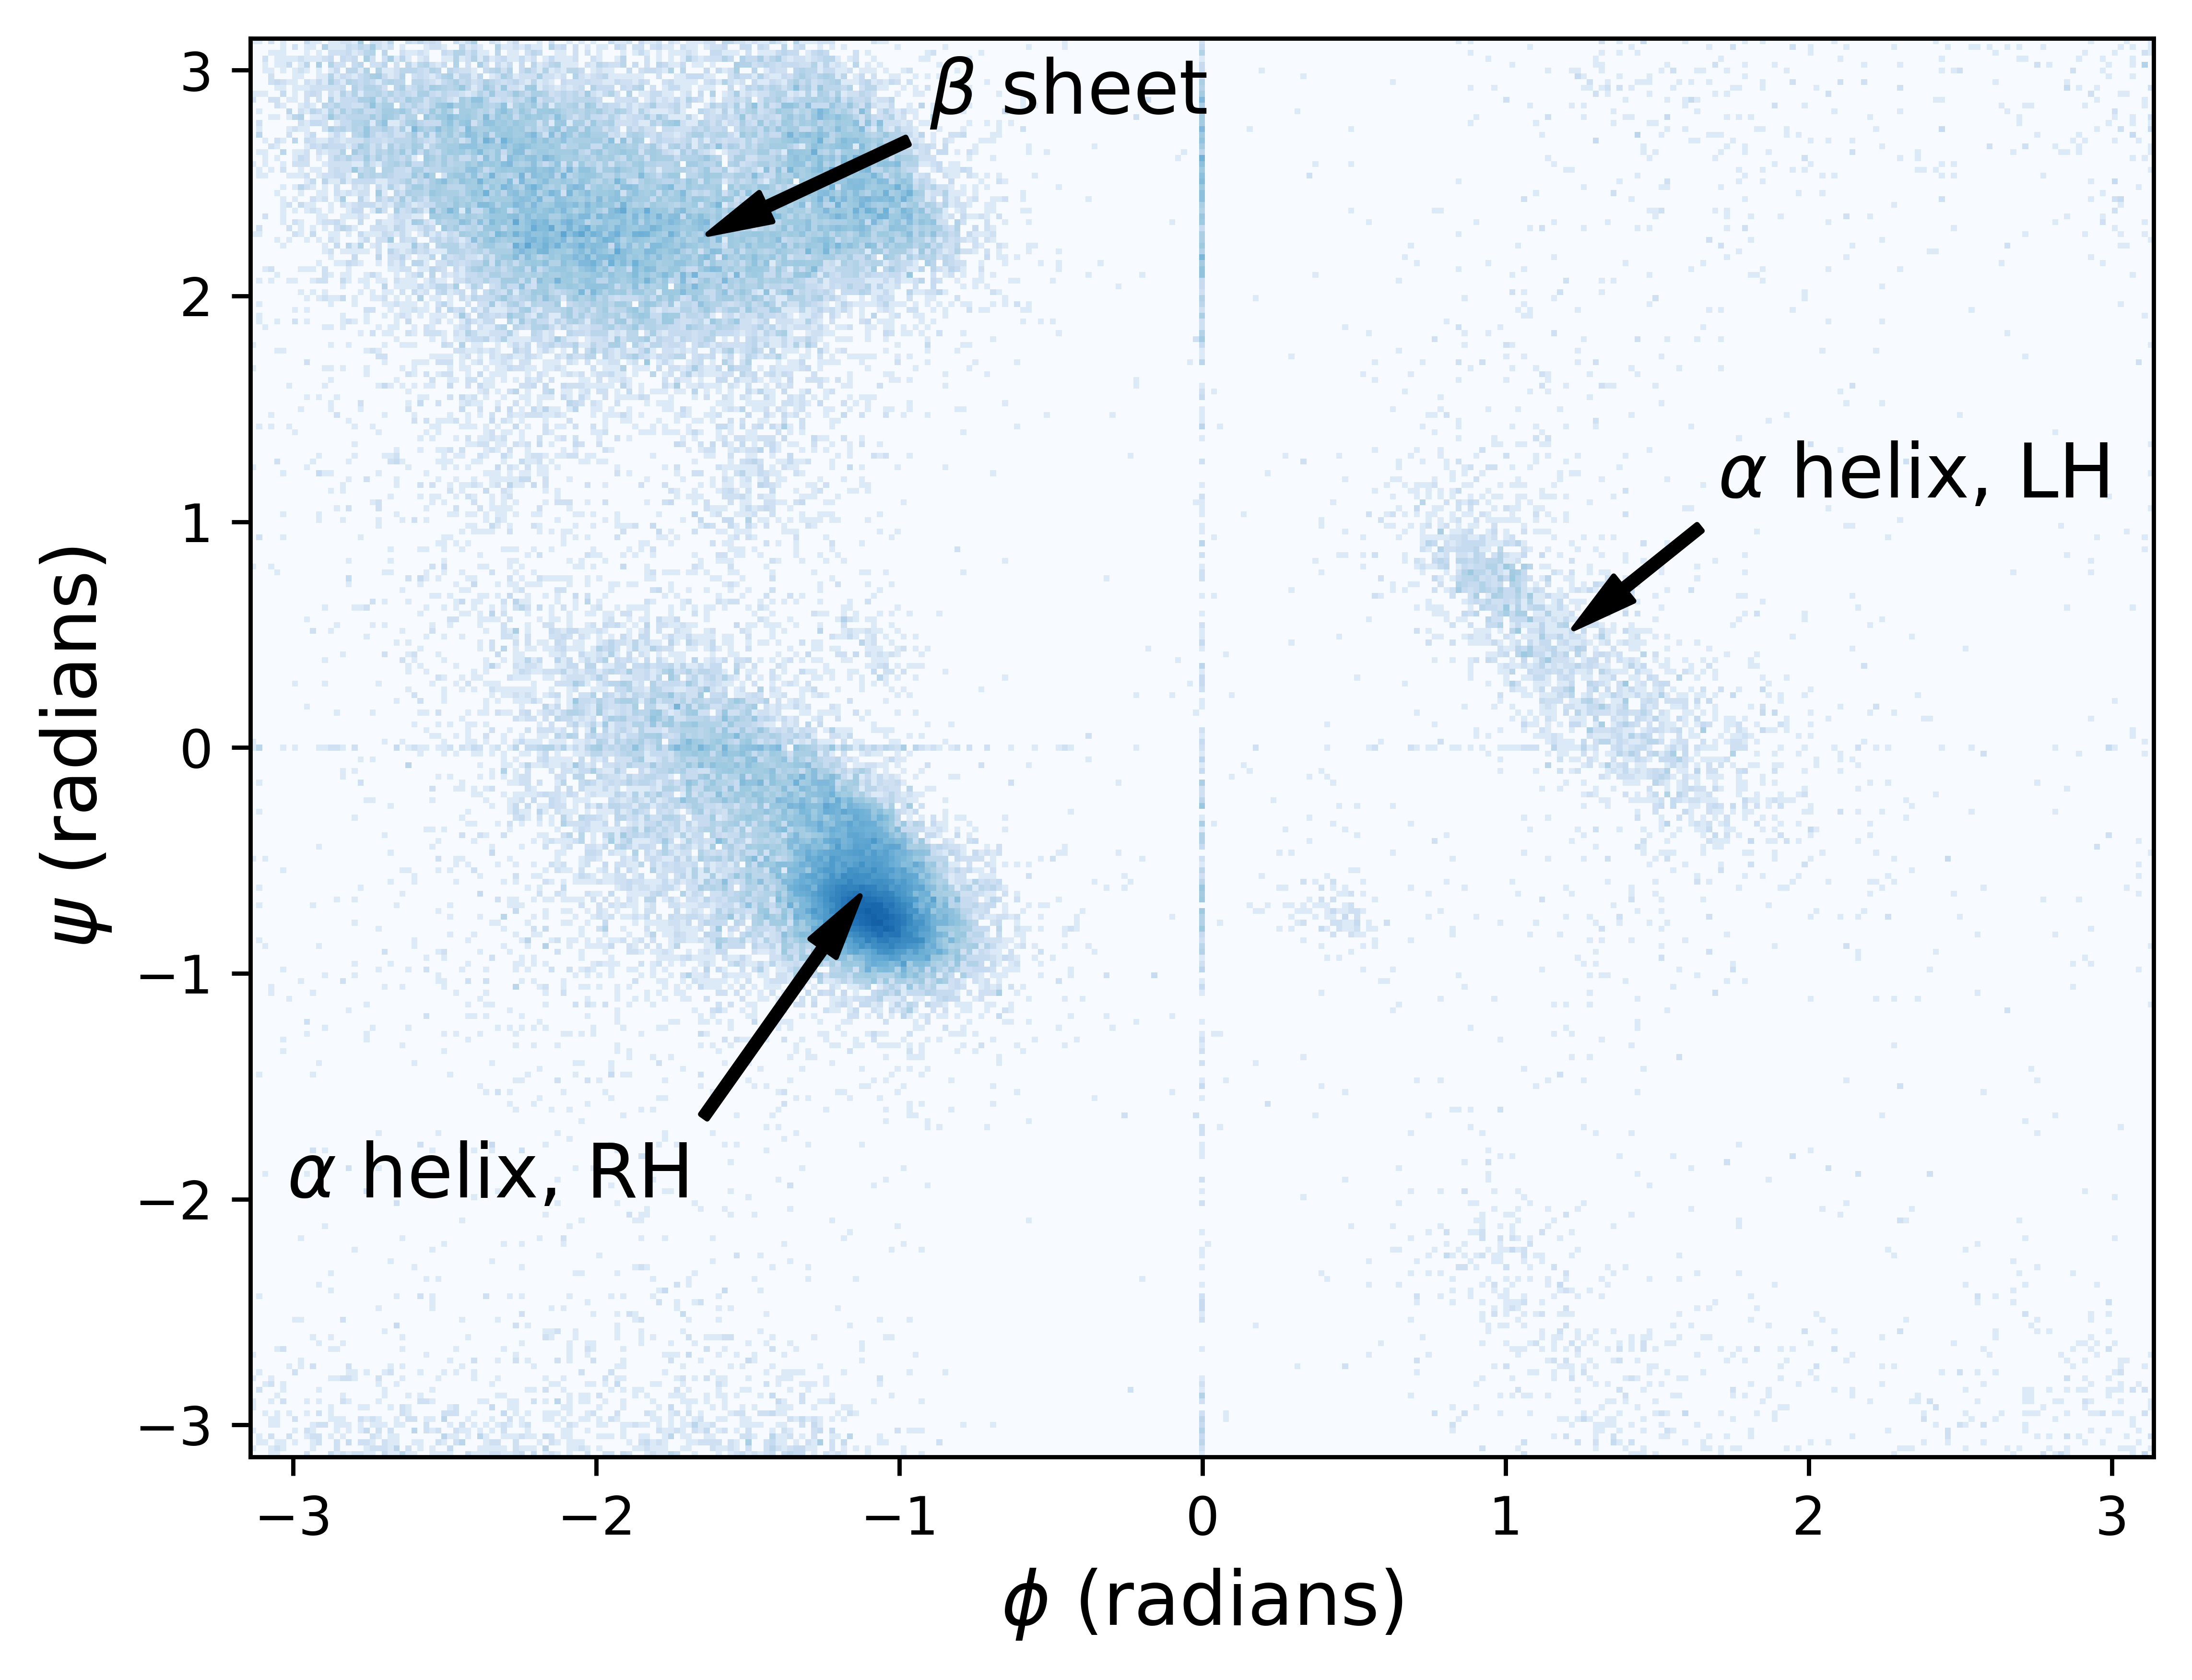

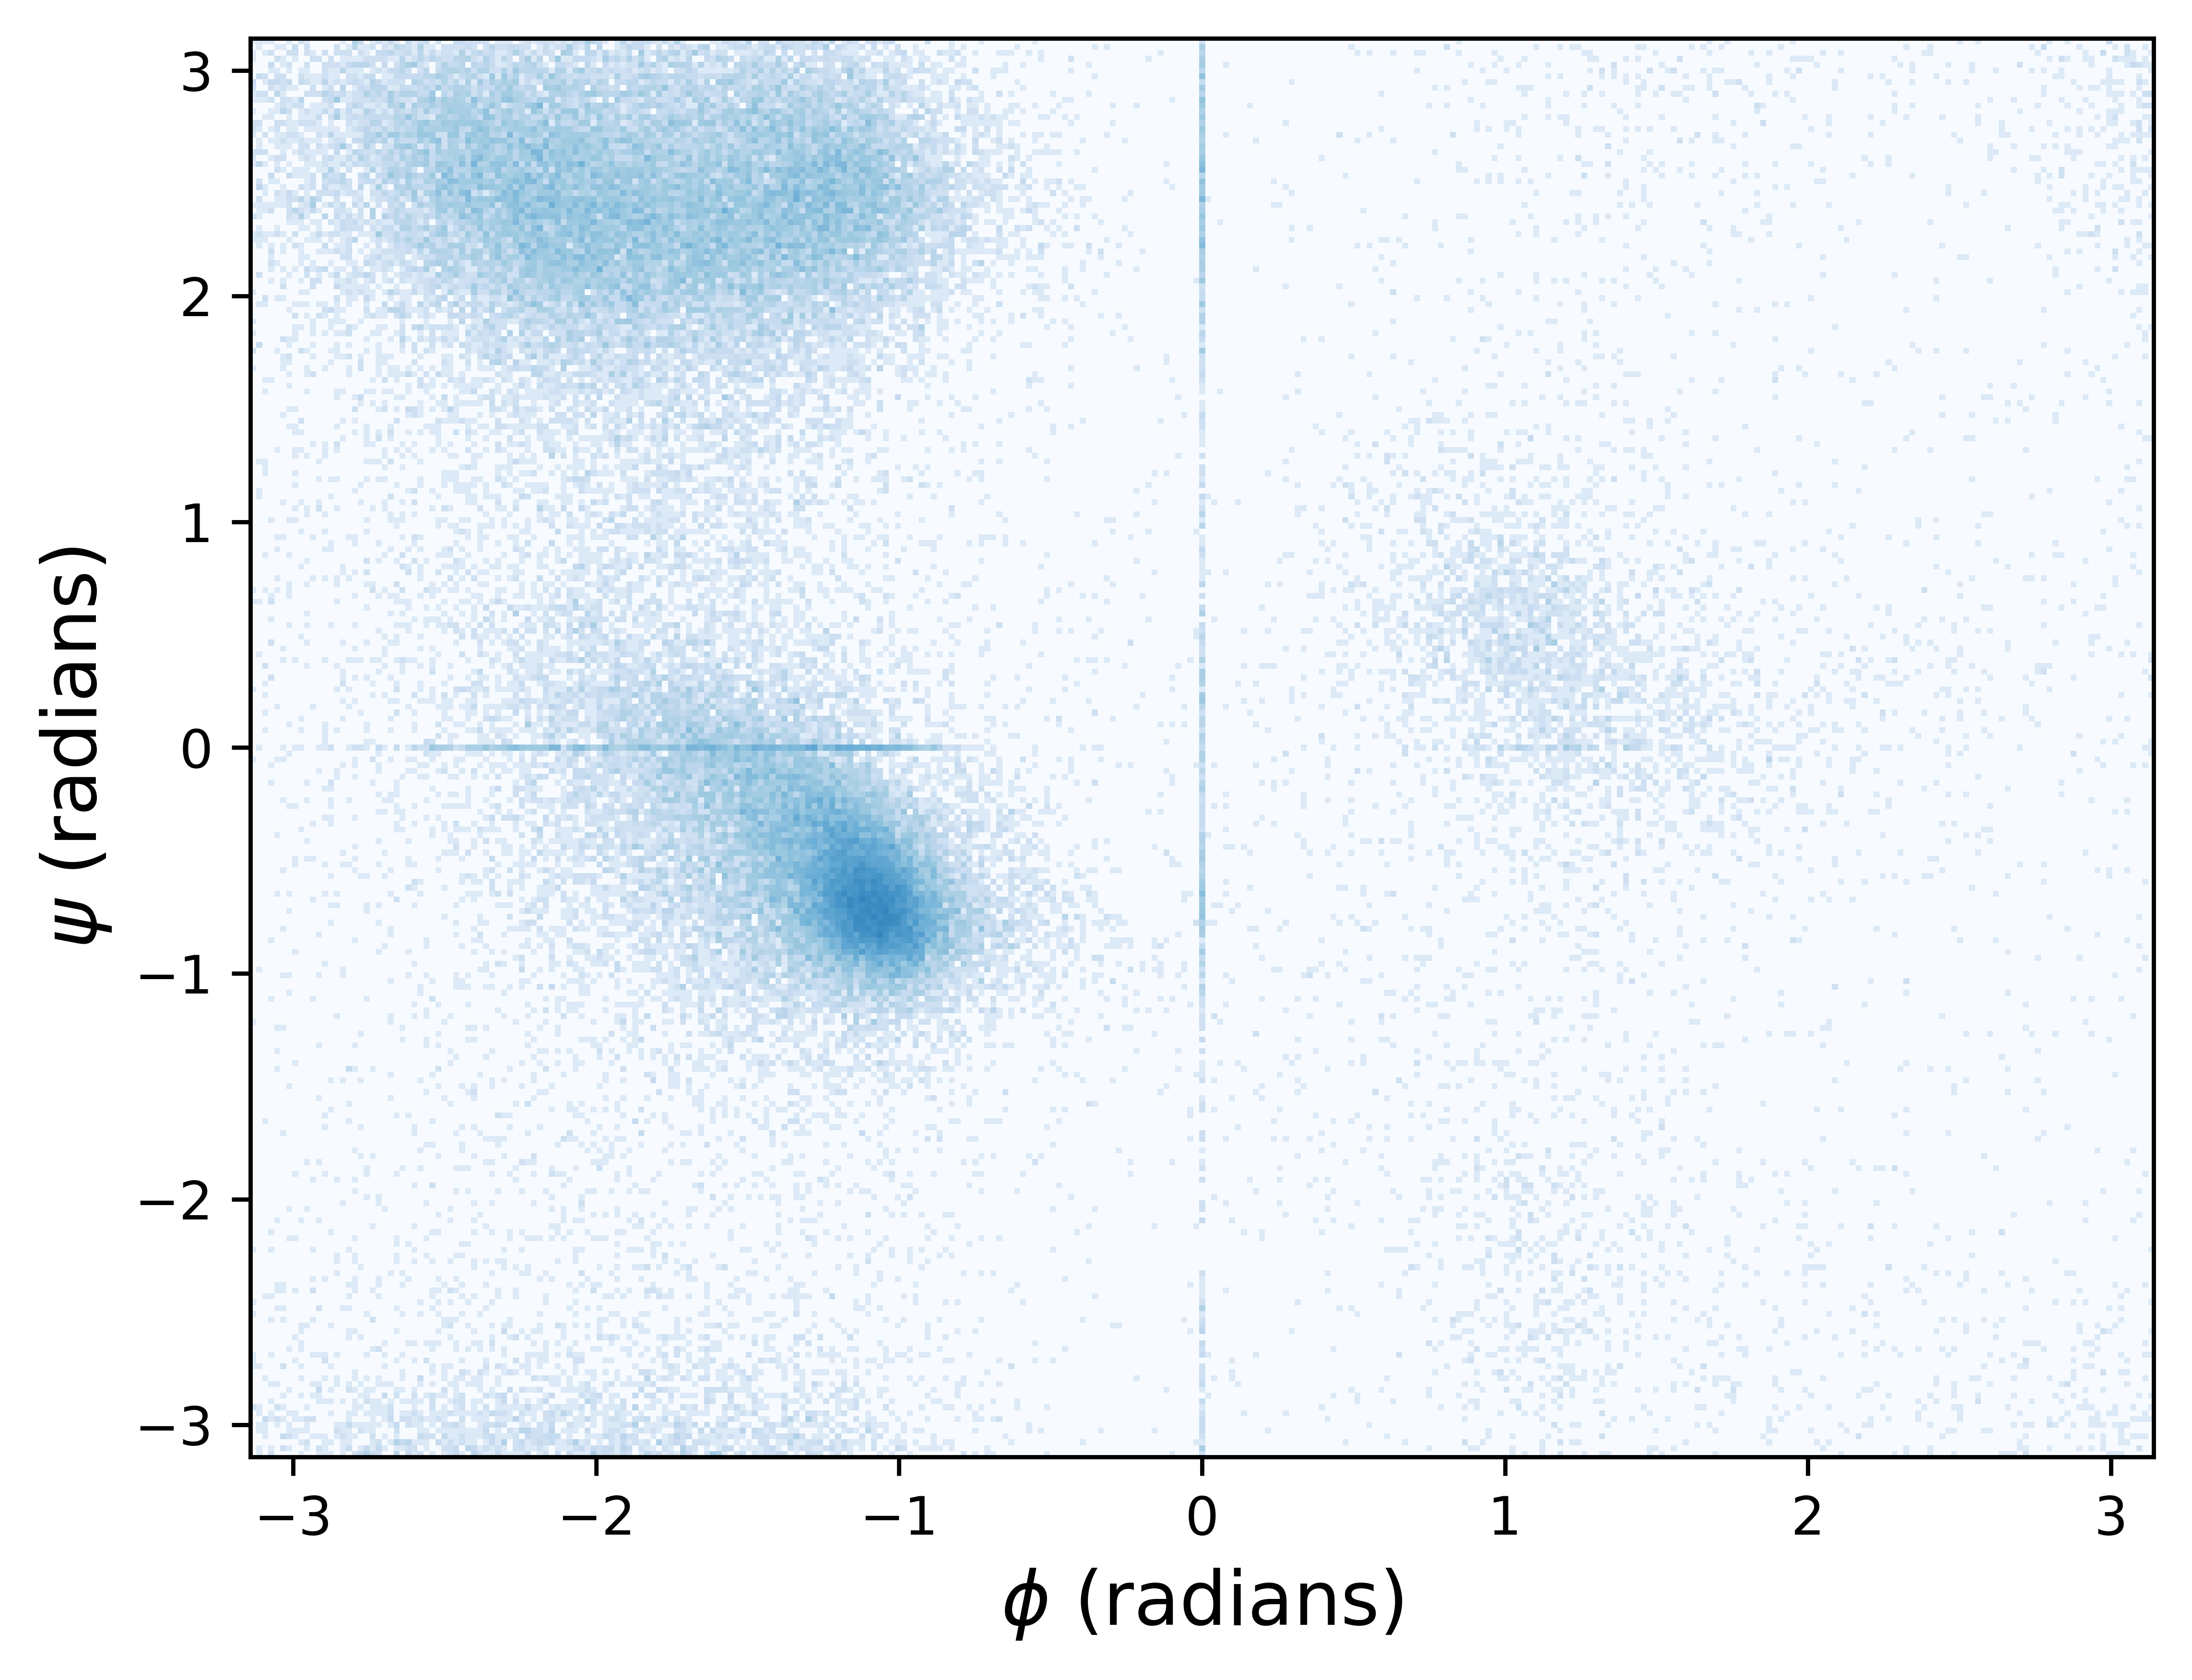

In [ ]:
phi_idx = test_dset.feature_names["angles"].index("phi")
psi_idx = test_dset.feature_names["angles"].index("psi")

rng = np.random.default_rng(seed=6489)
ram_idx = rng.choice(
    len(test_values_stacked), size=len(final_sampled_stacked), replace=True
)

plot_ramachandran(
    test_values_stacked[ram_idx, phi_idx],
    test_values_stacked[ram_idx, psi_idx],
    annot_ss=True,
    fname="plots/ramachandran_test_annot.pdf",
)

plot_ramachandran(
    final_sampled_stacked[:, phi_idx],
    final_sampled_stacked[:, psi_idx],
    max_seq_len=test_dset.dset.pad,
    fname="plots/ramachandran_generated.pdf",
)

In [84]:
import glob
pdb_files = glob.glob('generations/*.pdb')

In [85]:
len(pdb_files)

801

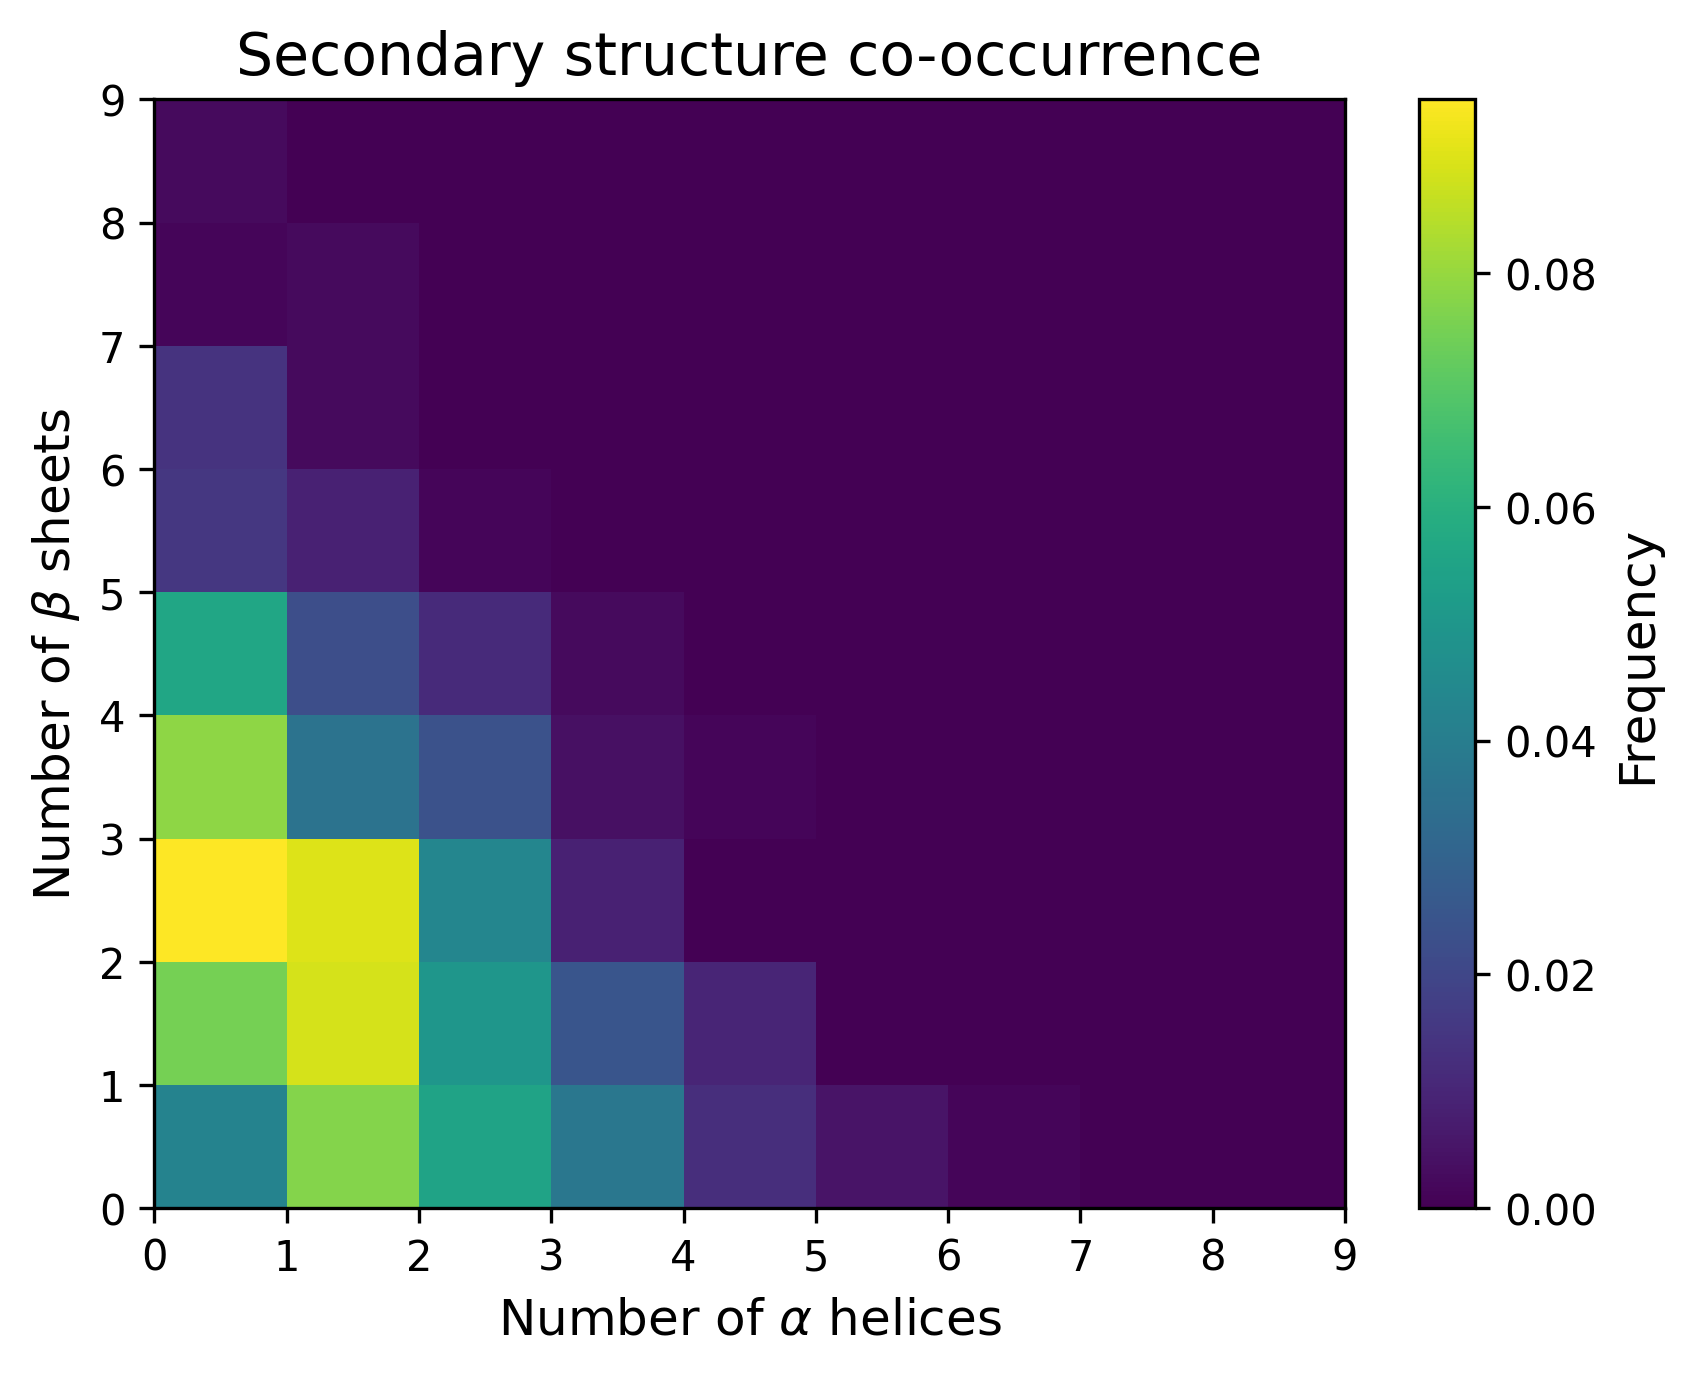

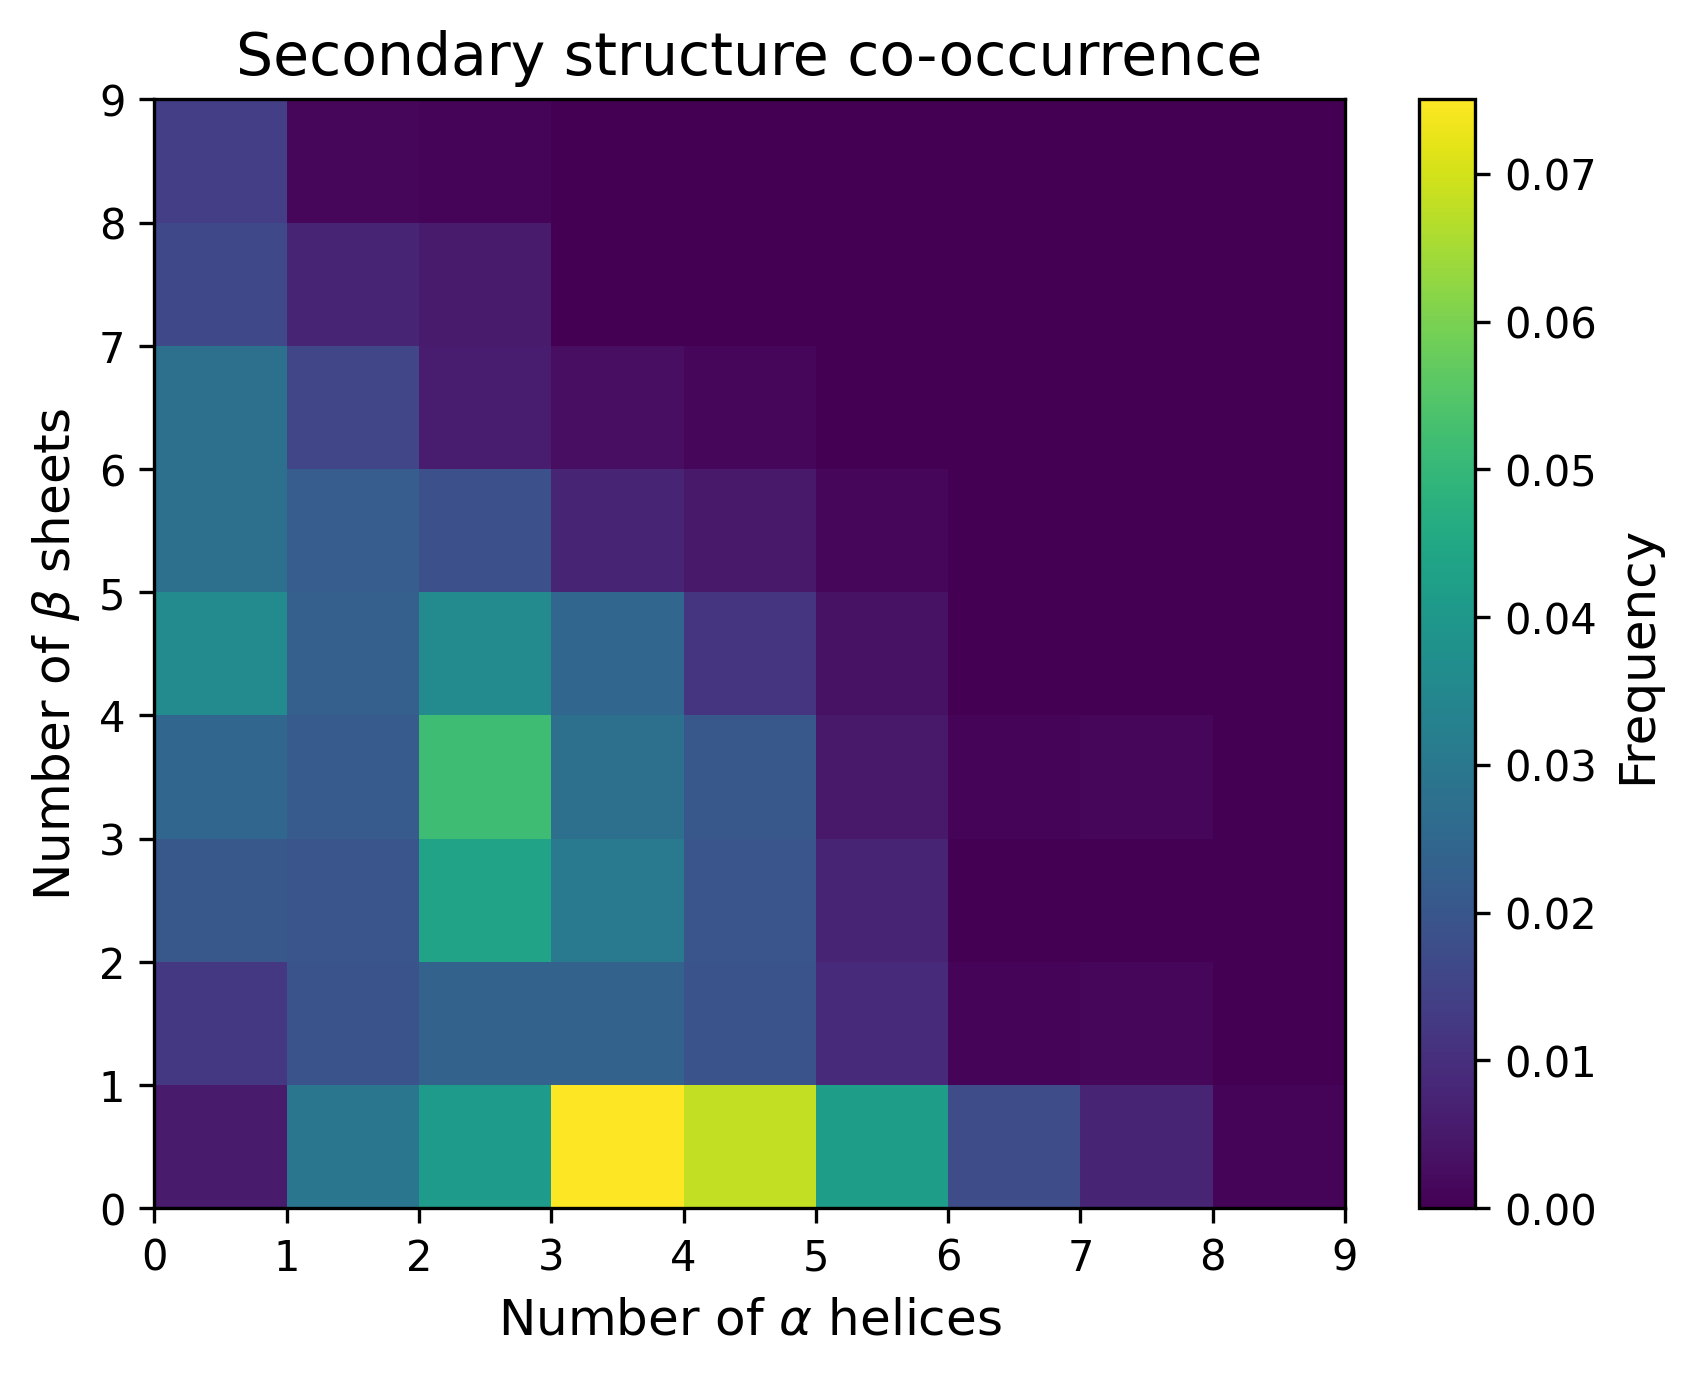

In [86]:
import warnings
warnings.filterwarnings("ignore", ".*elements were guessed from atom name.*")
make_ss_cooccurrence_plot(
    pdb_files,
    "plots/ss_cooccurrence_sampled.pdf",
    threads=multiprocessing.cpu_count(),
)
make_ss_cooccurrence_plot(
    test_dset.filenames,
    "plots/ss_cooccurrence_test.pdf",
    max_seq_len=test_dset.pad,
    threads=multiprocessing.cpu_count(),
)

In [89]:
angles_rec = sample(80, n_samples=4, n_steps=1000)

In [105]:
rec_pdb = write_pdb(angles_rec[0].cpu().numpy(), 'rec_prot.pdb')

In [106]:
def plot_protein(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("prot", pdb_file)
    view = nv.show_biopython(structure)
    return view

In [107]:
plot_protein(rec_pdb)

NGLWidget()